# Live Context Caching & AI Cost Optimization Demo

This notebook uses **real OpenAI API calls**, **Redis caches**, and **LangChain** to measure how caching strategies affect cost, latency, and token usage.

**Strategies demonstrated:**
1. Baseline (no caching)
2. Exact response reuse (Redis)
3. Semantic response cache (OpenAI embeddings + Redis)
4. Context reuse for RAG retrieval (Redis)
5. Provider-style prompt prefix caching (modeled via Redis)
6. Token optimization (compact prompts)
7. Combined cache stack
8. Versioned invalidation (stale cache detection)

## 0) Setup & health checks

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

# Ensure project root is on path
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from demo_core.config import check_redis_connection, load_config
from demo_core.llm_runner import LiveLLMRunner
from demo_core.metrics import count_tokens, format_summary_for_display, summarize_results
from demo_core.redis_cache import create_redis_client
from demo_core.workload import (
    STATIC_INSTRUCTIONS,
    TOOL_SCHEMA,
    StrategyConfig,
    build_prompt,
    make_workload,
    retrieve_context,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 60)

config = load_config()
redis_ok = check_redis_connection(config.redis_url)

print(f"Model: {config.openai_model}")
print(f"Embedding model: {config.embedding_model}")
print(f"Redis URL: {config.redis_url}")
print(f"Redis reachable: {redis_ok}")
assert redis_ok, "Start Redis with: docker compose up -d"

Model: gpt-4o-mini
Embedding model: text-embedding-3-small
Redis URL: redis://localhost:6379/0
Redis reachable: True


## 1) Build workload

Repeated enterprise-support questions with exact duplicates and paraphrases across 6 intents.

In [2]:
DEMO_ROUNDS = int(os.getenv("DEMO_ROUNDS", "3"))  # Use 1 for quick smoke test
requests = make_workload(rounds=DEMO_ROUNDS)

static_tokens = count_tokens(STATIC_INSTRUCTIONS + "\n\n" + TOOL_SCHEMA, config.openai_model)
example_prompt = build_prompt(
    requests[0],
    retrieve_context(requests[0].intent, 1, optimized=False),
    optimized=False,
    cache_friendly_order=True,
)
full_tokens = count_tokens(example_prompt, config.openai_model)

print(f"Requests: {len(requests)}")
print(f"Static instruction tokens: {static_tokens:,}")
print(f"Example full prompt tokens: {full_tokens:,}")

display(pd.DataFrame([r.__dict__ for r in requests[:5]]))

Requests: 54
Static instruction tokens: 829
Example full prompt tokens: 992


,req_id,question,intent,user_id,tenant_id,seconds_since_start
0,0,How long does a customer have to challenge billing?,billing,user-0,acme,0
1,1,I forgot my password and cannot sign in. Please keep the...,login,user-1,acme,18
2,2,Can an outage qualify for SLA credits? Please keep the a...,sla,user-2,acme,36
3,3,Please delete my personal data from the system. Please k...,privacy,user-3,acme,54
4,4,How do we handle MFA reset for an account? Please keep t...,login,user-4,acme,72


## 2) Initialize live runner

LangChain + OpenAI + Redis cache layers.

In [3]:
redis_client = create_redis_client(config.redis_url)
runner = LiveLLMRunner(config, redis_client)
print("LiveLLMRunner ready.")

LiveLLMRunner ready.


## 3) Run all strategies

Each strategy clears Redis caches before running so results are independent.

In [4]:
strategies = [
    StrategyConfig("Baseline"),
    StrategyConfig("Provider prompt cache", prompt_cache=True),
    StrategyConfig("KV prefix cache", kv_prefix_cache=True),
    StrategyConfig("Exact response reuse", exact_response_cache=True),
    StrategyConfig("Semantic response cache", semantic_response_cache=True, semantic_threshold=0.82),
    StrategyConfig("Context reuse", context_cache=True),
    StrategyConfig("Token optimization", token_optimization=True),
    StrategyConfig(
        "Combined cache stack",
        prompt_cache=True,
        exact_response_cache=True,
        semantic_response_cache=True,
        context_cache=True,
        semantic_threshold=0.82,
    ),
    StrategyConfig(
        "Combined + token optimization",
        prompt_cache=True,
        exact_response_cache=True,
        semantic_response_cache=True,
        context_cache=True,
        token_optimization=True,
        semantic_threshold=0.82,
    ),
]

all_results = []
for s in strategies:
    print(f"Running: {s.name} ...")
    df = runner.run_strategy(s, requests, clear_caches=True)
    all_results.append(df)
    print(f"  -> {len(df)} requests, LLM calls: {(df['source'] == 'llm').sum()}, cost: ${df['cost_usd'].sum():.4f}")

results_df = pd.concat(all_results, ignore_index=True)
summary = summarize_results(results_df, baseline_name="Baseline")
display(format_summary_for_display(summary))

Running: Baseline ...
  -> 54 requests, LLM calls: 54, cost: $0.0104
Running: Provider prompt cache ...
  -> 54 requests, LLM calls: 54, cost: $0.0066
Running: KV prefix cache ...
  -> 54 requests, LLM calls: 54, cost: $0.0104
Running: Exact response reuse ...
  -> 54 requests, LLM calls: 30, cost: $0.0057
Running: Semantic response cache ...
  -> 54 requests, LLM calls: 21, cost: $0.0040
Running: Context reuse ...
  -> 54 requests, LLM calls: 54, cost: $0.0103
Running: Token optimization ...
  -> 54 requests, LLM calls: 54, cost: $0.0027
Running: Combined cache stack ...
  -> 54 requests, LLM calls: 21, cost: $0.0026
Running: Combined + token optimization ...
  -> 54 requests, LLM calls: 21, cost: $0.0010


,strategy,requests,llm_calls,total_cost_usd,avg_latency_ms,p95_latency_ms,cached_billable_tokens,cached_compute_tokens,cache_hits,cost_reduction_%,latency_reduction_%,stale_hits
0,Combined + token optimization,54,21,$0.0010,661,2323,0,0,48,90.1,61.3,0
1,Combined cache stack,54,21,$0.0026,666,2095,18560,18560,53,74.6,61.1,0
2,Token optimization,54,54,$0.0027,1805,2496,0,0,0,73.8,-5.6,0
3,Semantic response cache,54,21,$0.0040,628,1768,0,0,33,61.2,63.3,0
4,Exact response reuse,54,30,$0.0057,1047,2378,0,0,24,44.6,38.8,0
5,Provider prompt cache,54,54,$0.0066,1924,3342,50240,50240,53,36.3,-12.5,0
6,Context reuse,54,54,$0.0103,1699,2483,0,0,48,0.1,0.6,0
7,Baseline,54,54,$0.0104,1709,2132,0,0,0,0.0,0.0,0
8,KV prefix cache,54,54,$0.0104,2235,4501,0,50240,53,-0.1,-30.8,0


## 4) Visualize cost & latency savings

/var/folders/jm/c7g6tgcj5294q52jhq1vyw240000gp/T/ipykernel_1915/1184201558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="total_cost_usd", y="strategy", ax=axes[0], palette="Blues_r")
/var/folders/jm/c7g6tgcj5294q52jhq1vyw240000gp/T/ipykernel_1915/1184201558.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="avg_latency_ms", y="strategy", ax=axes[1], palette="Greens_r")


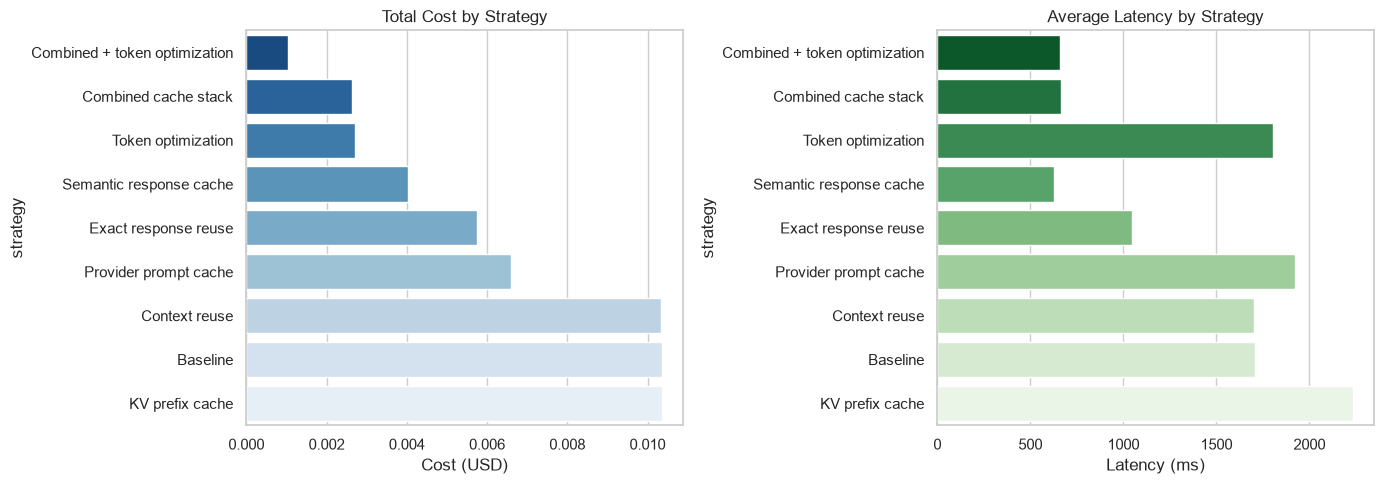

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = summary.sort_values("total_cost_usd")
sns.barplot(data=plot_df, x="total_cost_usd", y="strategy", ax=axes[0], palette="Blues_r")
axes[0].set_title("Total Cost by Strategy")
axes[0].set_xlabel("Cost (USD)")

sns.barplot(data=plot_df, x="avg_latency_ms", y="strategy", ax=axes[1], palette="Greens_r")
axes[1].set_title("Average Latency by Strategy")
axes[1].set_xlabel("Latency (ms)")

plt.tight_layout()
plt.show()

## 5) Cache hit breakdown

In [6]:
hit_breakdown = (
    results_df.groupby(["strategy", "source"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
display(hit_breakdown)

combined = results_df[results_df["strategy"] == "Combined cache stack"]
cache_events = combined["cache_event"].value_counts()
print("\nCombined cache stack — cache events:")
print(cache_events.to_string())

source,strategy,exact_response_cache,llm,semantic_response_cache
0,Baseline,0,54,0
1,Combined + token optimization,15,21,18
2,Combined cache stack,15,21,18
3,Context reuse,0,54,0
4,Exact response reuse,24,30,0
5,KV prefix cache,0,54,0
6,Provider prompt cache,0,54,0
7,Semantic response cache,0,21,33
8,Token optimization,0,54,0



Combined cache stack — cache events:
cache_event
prompt_cache_hit     20
exact_hit            15
semantic_hit@0.88     6
semantic_hit@0.93     2
semantic_hit@0.89     2
semantic_hit@0.87     2
semantic_hit@0.92     2
semantic_hit@0.91     2
semantic_hit@0.94     2
miss                  1


## 6) Versioned invalidation demo

Simulate a policy update mid-run. Without version keys, stale answers can be served from cache.

In [7]:
update_at = len(requests) // 2

stale_cfg = StrategyConfig(
    "Stale risk (no version keys)",
    exact_response_cache=True,
    include_versions_in_keys=False,
    update_docs_at=update_at,
)
safe_cfg = StrategyConfig(
    "Safe invalidation (version keys)",
    exact_response_cache=True,
    include_versions_in_keys=True,
    update_docs_at=update_at,
)

stale_df = runner.run_strategy(stale_cfg, requests, clear_caches=True)
safe_df = runner.run_strategy(safe_cfg, requests, clear_caches=True)

invalidation = pd.DataFrame([
    {"strategy": stale_cfg.name, "stale_hits": stale_df["stale_hit"].sum(), "llm_calls": (stale_df["source"] == "llm").sum()},
    {"strategy": safe_cfg.name, "stale_hits": safe_df["stale_hit"].sum(), "llm_calls": (safe_df["source"] == "llm").sum()},
])
display(invalidation)
display(Markdown(
    f"**Policy update at request #{update_at}** (refund window changes 30→45 days). "
    "Version keys in cache scope prevent serving outdated answers."
))

,strategy,stale_hits,llm_calls
0,Stale risk (no version keys),13,30
1,Safe invalidation (version keys),0,41


**Policy update at request #27** (refund window changes 30→45 days). Version keys in cache scope prevent serving outdated answers.

## 7) Inspect Redis cache keys (transparency)

In [8]:
# Run combined strategy once more to populate caches
combined_cfg = StrategyConfig(
    "Combined cache stack",
    prompt_cache=True,
    exact_response_cache=True,
    semantic_response_cache=True,
    context_cache=True,
    semantic_threshold=0.82,
)
runner.run_strategy(combined_cfg, requests[:6], clear_caches=True)

sample_keys = []
for prefix in ["exact:", "context:", "semantic:", "prompt_prefix:", "kv_prefix:"]:
    cursor, keys = redis_client.scan(cursor=0, match=f"{prefix}*", count=10)
    for k in keys[:3]:
        sample_keys.append({"namespace": prefix.rstrip(":"), "key": k})

display(pd.DataFrame(sample_keys))
print(f"\nTotal Redis keys (all demo namespaces): ", end="")
total = 0
for prefix in ["exact:", "context:", "semantic:", "prompt_prefix:", "kv_prefix:"]:
    cursor = 0
    while True:
        cursor, keys = redis_client.scan(cursor=cursor, match=f"{prefix}*", count=200)
        total += len(keys)
        if cursor == 0:
            break
print(total)

,namespace,key
0,exact,exact:be9fe1c31e8fa0d0
1,exact,exact:5b655bc9377deb04
2,exact,exact:937208f01cad4448
3,context,context:tenant:acme|intent:privacy|docs:1|prompt:v1-full
4,context,context:tenant:acme|intent:billing|docs:1|prompt:v1-full
5,semantic,semantic:tenant:acme|model:gpt-4o-mini|docs:1|prompt:v1-...
6,semantic,semantic:index:tenant:acme|model:gpt-4o-mini|docs:1|prom...
7,semantic,semantic:tenant:acme|model:gpt-4o-mini|docs:1|prompt:v1-...
8,prompt_prefix,prompt_prefix:scope:tenant:acme|model:gpt-4o-mini|prompt...



Total Redis keys (all demo namespaces): 19


## 8) Sample answers (quality check)

In [9]:
sample = results_df[results_df["strategy"] == "Baseline"].head(3)
for _, row in sample.iterrows():
    print(f"Q#{row['req_id']} [{row['intent']}]: {row['answer_preview']}...")
    print(f"  tokens in/out: {row['input_tokens']}/{row['output_tokens']}, latency: {row['latency_ms']:.0f}ms, cost: ${row['cost_usd']:.5f}")
    print()

Q#0 [billing]: **Summary:** A customer has 15 days to raise disputes regarding charges on their...
  tokens in/out: 1019/63, latency: 2113ms, cost: $0.00019

Q#1 [login]: **Summary:** To reset your password, you need to verify your email.

**Policy Ba...
  tokens in/out: 1024/51, latency: 1450ms, cost: $0.00018

Q#2 [sla]: **Summary:** Yes, an outage can qualify for SLA credits, but it requires a suppo...
  tokens in/out: 1024/60, latency: 1759ms, cost: $0.00019

